In [40]:
#Create the /analytics folder

import os

os.makedirs("/content/analytics", exist_ok=True)
os.makedirs("/content/analytics/charts", exist_ok=True)

print("Analytics folder created successfully!")

Analytics folder created successfully!


In [41]:
# Install required packages

!pip install -q imbalanced-learn joblib

In [42]:
# Import all libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [43]:
# Load Titanic Dataset

df = sns.load_dataset("titanic")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (891, 15)


In [44]:
df.to_csv("/content/analytics/titanic.csv", index=False)

print("titanic.csv saved successfully!")

titanic.csv saved successfully!


In [45]:
# Basic profiling

print("DATASET SHAPE")
print(df.shape)

print("\n" + "="*60)
print("DATASET INFORMATION")
print("="*60)

df.info()

print("\n" + "="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)

display(df.describe(include="all"))

DATASET SHAPE
(891, 15)

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

DESCRIPTIVE STATISTICS


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.0000,891.0000,891,714.0000,891.0000,891.0000,891.0000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.3838,2.3086,NaN,29.6991,0.5230,0.3816,32.2042,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.4866,0.8361,NaN,14.5265,1.1027,0.8061,49.6934,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.0000,1.0000,NaN,0.4200,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.0000,2.0000,NaN,20.1250,0.0000,0.0000,7.9104,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.0000,3.0000,NaN,28.0000,0.0000,0.0000,14.4542,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.0000,3.0000,NaN,38.0000,1.0000,0.0000,31.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [46]:
# Missing-value percentage

missing_count = df.isnull().sum()
missing_percentage = (df.isnull().mean() * 100)

missing_report = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

missing_report = missing_report[
    missing_report["Missing Count"] > 0
].sort_values(
    "Missing Percentage",
    ascending=False
)

display(missing_report)

,Missing Count,Missing Percentage
deck,688,77.2166
age,177,19.8653
embarked,2,0.2245
embark_town,2,0.2245


In [47]:
# Clean the dataset

clean_df = df.copy()

In [48]:
clean_df = clean_df.drop(columns=["deck"])

print("Shape after dropping deck:", clean_df.shape)

Shape after dropping deck: (891, 14)


In [49]:
clean_df = clean_df.dropna(
    subset=["embarked", "embark_town"]
)

print("Shape after removing rows with missing embarked/embark_town:")
print(clean_df.shape)

Shape after removing rows with missing embarked/embark_town:
(889, 14)


In [50]:
age_median = clean_df["age"].median()

clean_df["age"] = clean_df["age"].fillna(age_median)

print("Age median used for imputation:", age_median)
print("Remaining missing age values:", clean_df["age"].isnull().sum())

Age median used for imputation: 28.0
Remaining missing age values: 0


In [51]:
print("Remaining missing values:")
display(clean_df.isnull().sum())

Remaining missing values:


,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [52]:
# Verify cleaning

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", clean_df.shape)

print("\nMissing values after cleaning:")
display(clean_df.isnull().sum())

Original dataset shape: (891, 15)
Cleaned dataset shape: (889, 14)

Missing values after cleaning:


,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


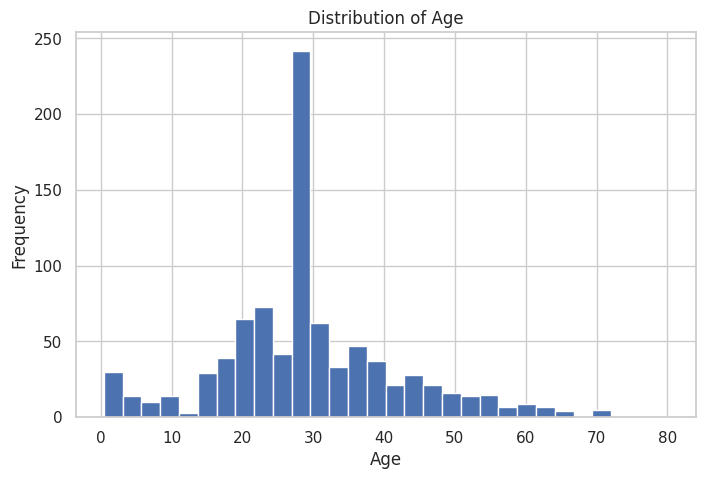

In [53]:
#  Age histogram

plt.figure(figsize=(8, 5))

plt.hist(clean_df["age"], bins=30)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

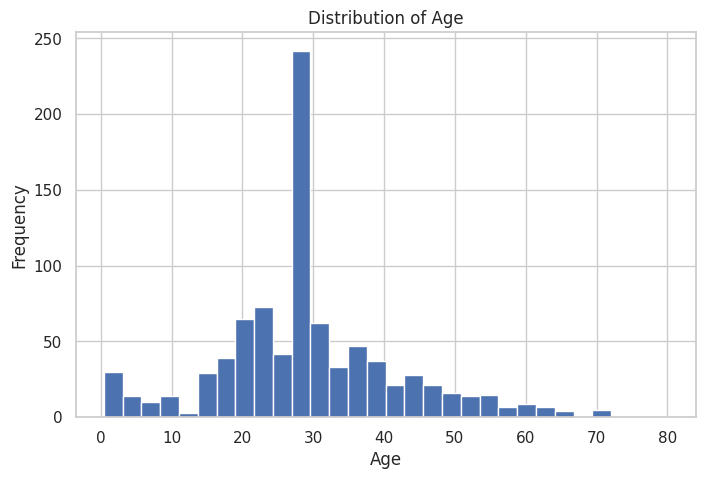

In [54]:
# Save the chart

plt.figure(figsize=(8, 5))

plt.hist(clean_df["age"], bins=30)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.savefig(
    "/content/analytics/charts/age_histogram.png",
    bbox_inches="tight"
)

plt.show()

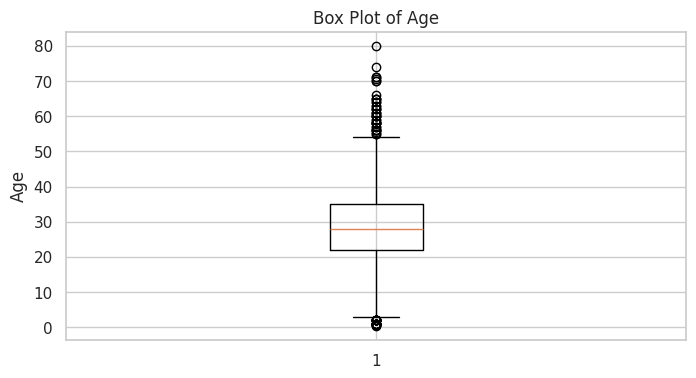

In [55]:
# Age box plot

plt.figure(figsize=(8, 4))

plt.boxplot(clean_df["age"])

plt.title("Box Plot of Age")
plt.ylabel("Age")

plt.savefig(
    "/content/analytics/charts/age_boxplot.png",
    bbox_inches="tight"
)

plt.show()

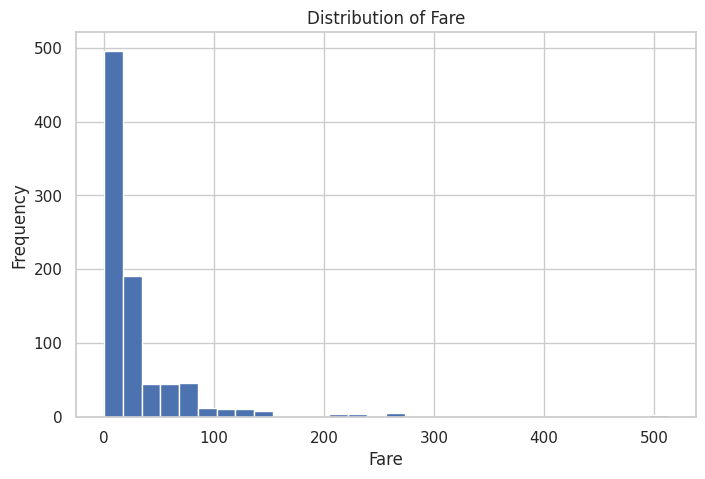

In [56]:
# Fare histogram

plt.figure(figsize=(8, 5))

plt.hist(clean_df["fare"], bins=30)

plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.savefig(
    "/content/analytics/charts/fare_histogram.png",
    bbox_inches="tight"
)

plt.show()

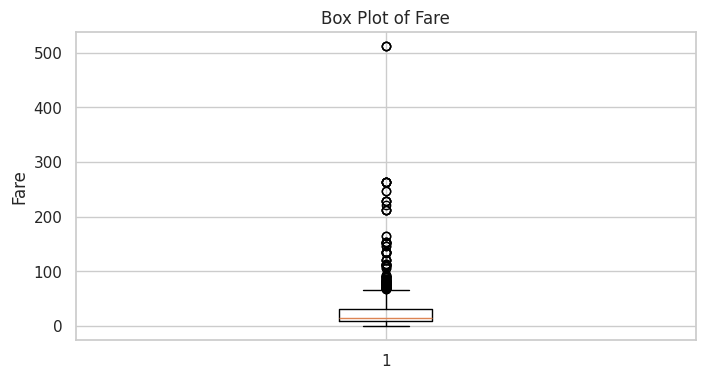

In [57]:
# Fare box plot

plt.figure(figsize=(8, 4))

plt.boxplot(clean_df["fare"])

plt.title("Box Plot of Fare")
plt.ylabel("Fare")

plt.savefig(
    "/content/analytics/charts/fare_boxplot.png",
    bbox_inches="tight"
)

plt.show()

In [58]:
# Calculate IQR outliers

def calculate_iqr_outliers(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    print(f"\nColumn: {column}")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))

    return outliers


age_outliers = calculate_iqr_outliers(clean_df, "age")
fare_outliers = calculate_iqr_outliers(clean_df, "fare")


Column: age
Q1: 22.0
Q3: 35.0
IQR: 13.0
Lower Bound: 2.5
Upper Bound: 54.5
Number of Outliers: 65

Column: fare
Q1: 7.8958
Q3: 31.0
IQR: 23.1042
Lower Bound: -26.7605
Upper Bound: 65.6563
Number of Outliers: 114


In [59]:
#  Fare mean, median and mode

fare_mean = clean_df["fare"].mean()
fare_median = clean_df["fare"].median()
fare_mode = clean_df["fare"].mode()[0]

print("Fare Mean:", fare_mean)
print("Fare Median:", fare_median)
print("Fare Mode:", fare_mode)

Fare Mean: 32.09668087739032
Fare Median: 14.4542
Fare Mode: 8.05


In [60]:
# determine skewness

print("\nOrdering:")

if fare_mean > fare_median > fare_mode:
    print("Mean > Median > Mode")
    print("Fare distribution is right-skewed.")

elif fare_mean < fare_median < fare_mode:
    print("Mean < Median < Mode")
    print("Fare distribution is left-skewed.")

else:
    print("The distribution does not follow a simple mean/median/mode ordering.")


Ordering:
Mean > Median > Mode
Fare distribution is right-skewed.


In [61]:
# Survival rate by Sex

survival_by_sex = clean_df.groupby("sex")["survived"].mean() * 100

print("Survival Rate by Sex:")
display(survival_by_sex)

Survival Rate by Sex:


,survived
sex,
female,74.0385
male,18.8908


In [62]:
# Survival rate by Pclass

survival_by_pclass = clean_df.groupby("pclass")["survived"].mean() * 100

print("Survival Rate by Passenger Class:")
display(survival_by_pclass)

Survival Rate by Passenger Class:


,survived
pclass,
1,62.6168
2,47.2826
3,24.2363


In [63]:
# Survival by Sex AND Pclass

survival_by_sex_pclass = (
    clean_df
    .groupby(["sex", "pclass"])["survived"]
    .mean()
    .reset_index()
)

survival_by_sex_pclass["survival_rate"] = (
    survival_by_sex_pclass["survived"] * 100
)

survival_by_sex_pclass = survival_by_sex_pclass.drop(
    columns=["survived"]
)

display(survival_by_sex_pclass)

,sex,pclass,survival_rate
0,female,1,96.7391
1,female,2,92.1053
2,female,3,50.0000
3,male,1,36.8852
4,male,2,15.7407
5,male,3,13.5447


In [64]:
# Use BOOLEAN MASKING

female_first_class = clean_df[
    (clean_df["sex"] == "female") &
    (clean_df["pclass"] == 1)
]

female_first_class_survival = female_first_class["survived"].mean() * 100

print(
    "Female passengers in 1st class survival rate:",
    female_first_class_survival
)

Female passengers in 1st class survival rate: 96.73913043478261


In [65]:
# check male passengers in third class

male_third_class = clean_df[
    (clean_df["sex"] == "male") &
    (clean_df["pclass"] == 3)
]

male_third_class_survival = male_third_class["survived"].mean() * 100

print(
    "Male passengers in 3rd class survival rate:",
    male_third_class_survival
)

Male passengers in 3rd class survival rate: 13.544668587896252


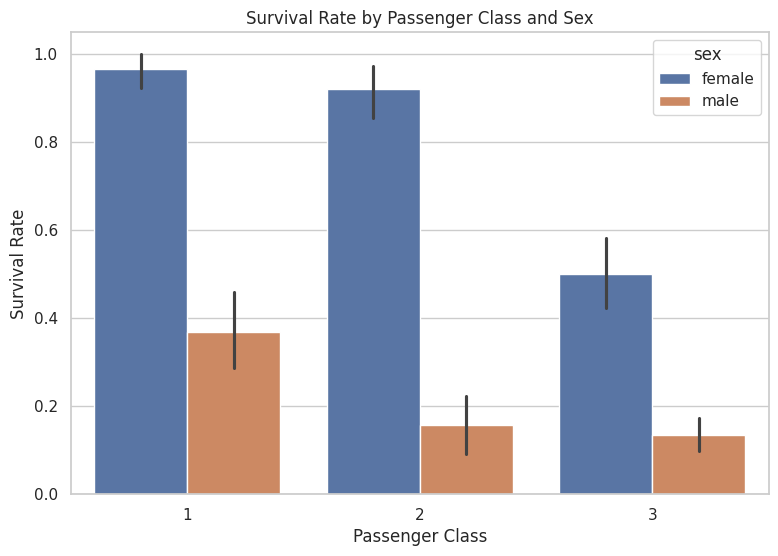

In [66]:
# Create a survival visualization

plt.figure(figsize=(9, 6))

sns.barplot(
    data=clean_df,
    x="pclass",
    y="survived",
    hue="sex"
)

plt.title("Survival Rate by Passenger Class and Sex")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.savefig(
    "/content/analytics/charts/survival_by_sex_pclass.png",
    bbox_inches="tight"
)

plt.show()

In [67]:
# Correlation Matrix

correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

correlation_matrix = clean_df[
    correlation_columns
].corr()

display(correlation_matrix)

,survived,pclass,age,sibsp,parch,fare
survived,1.0000,-0.3355,-0.0698,-0.0340,0.0832,0.2553
pclass,-0.3355,1.0000,-0.3365,0.0817,0.0168,-0.5482
age,-0.0698,-0.3365,1.0000,-0.2325,-0.1715,0.0937
sibsp,-0.0340,0.0817,-0.2325,1.0000,0.4145,0.1609
parch,0.0832,0.0168,-0.1715,0.4145,1.0000,0.2175
fare,0.2553,-0.5482,0.0937,0.1609,0.2175,1.0000


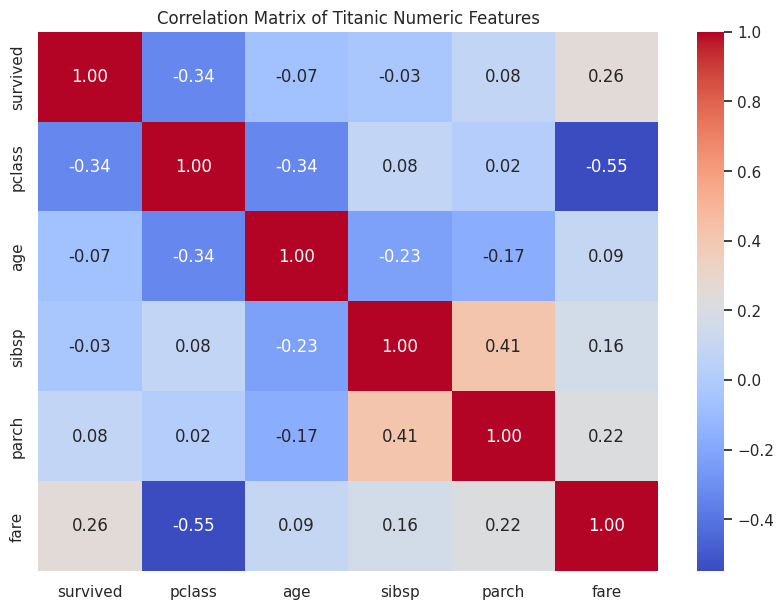

In [68]:
# Draw the required heatmap

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Titanic Numeric Features")

plt.savefig(
    "/content/analytics/charts/correlation_heatmap.png",
    bbox_inches="tight"
)

plt.show()



In [69]:
# absolute off-diagonal correlation coefficients

corr = correlation_matrix.copy()

# Remove the diagonal
np.fill_diagonal(corr.values, np.nan)

# Convert matrix into pairs
corr_pairs = (
    corr
    .stack()
    .reset_index()
)

corr_pairs.columns = [
    "Feature 1",
    "Feature 2",
    "Correlation"
]

# Remove duplicate pairs
corr_pairs["Pair"] = corr_pairs.apply(
    lambda row: tuple(sorted([row["Feature 1"], row["Feature 2"]])),
    axis=1
)

corr_pairs = corr_pairs.drop_duplicates("Pair")

# Calculate absolute correlation
corr_pairs["Absolute Correlation"] = (
    corr_pairs["Correlation"].abs()
)

# Sort strongest first
strongest_correlations = corr_pairs.sort_values(
    "Absolute Correlation",
    ascending=False
)

display(
    strongest_correlations[
        [
            "Feature 1",
            "Feature 2",
            "Correlation",
            "Absolute Correlation"
        ]
    ].head(2)
)

,Feature 1,Feature 2,Correlation,Absolute Correlation
9,pclass,fare,-0.5482,0.5482
18,sibsp,parch,0.4145,0.4145


## Two Strongest Correlations

The two strongest correlations were identified by ranking all off-diagonal
correlation coefficients using their absolute values.

The strongest correlation was between `pclass` and `fare`, with a correlation
of **-0.5482**. This moderate negative relationship indicates that passengers
in higher-numbered passenger classes generally paid lower fares. Since
`pclass=1` represents first class and `pclass=3` represents third class,
this relationship is consistent with the difference in ticket pricing across classes.

The second strongest correlation was between `sibsp` and `parch`, with a
correlation of **+0.4145**. This moderate positive relationship indicates that
passengers with more siblings or spouses aboard tended to also have more
parents or children aboard, reflecting differences in family-group travel.

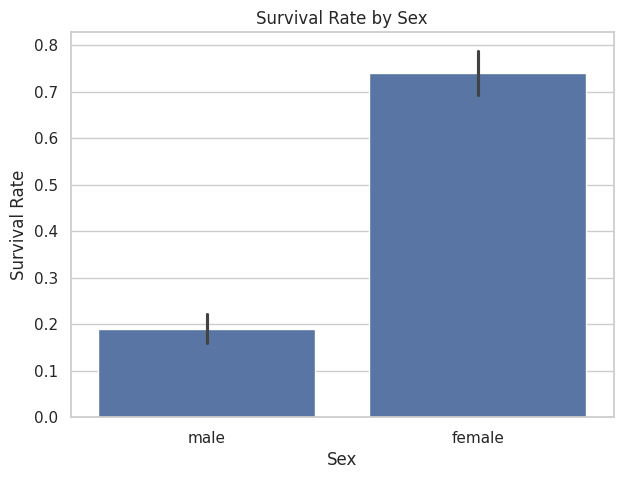

In [71]:
# survival by sex

plt.figure(figsize=(7, 5))

sns.barplot(
    data=clean_df,
    x="sex",
    y="survived"
)

plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")

plt.savefig(
    "/content/analytics/charts/survival_by_sex.png",
    bbox_inches="tight"
)

plt.show()

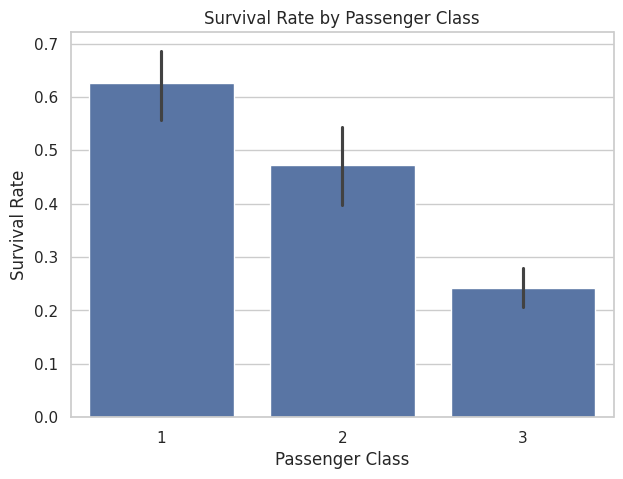

In [72]:
# survival by class

plt.figure(figsize=(7, 5))

sns.barplot(
    data=clean_df,
    x="pclass",
    y="survived"
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.savefig(
    "/content/analytics/charts/survival_by_pclass.png",
    bbox_inches="tight"
)

plt.show()

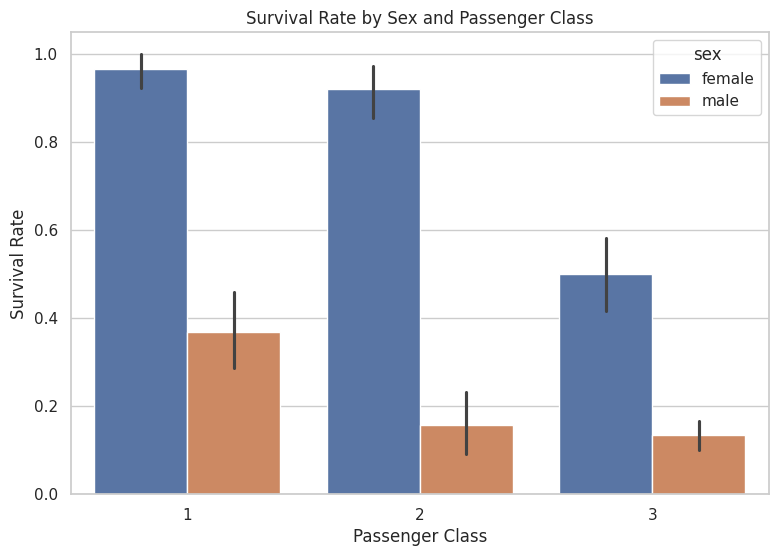

In [73]:
# Sex + Passenger Class Charts

plt.figure(figsize=(9, 6))

sns.barplot(
    data=clean_df,
    x="pclass",
    y="survived",
    hue="sex"
)

plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.savefig(
    "/content/analytics/charts/survival_by_sex_pclass.png",
    bbox_inches="tight"
)

plt.show()

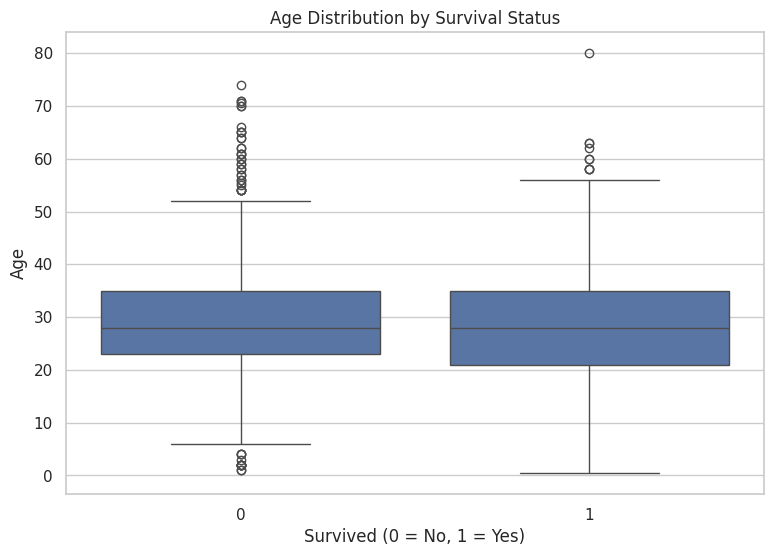

In [74]:
# Age distribution by survival

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=clean_df,
    x="survived",
    y="age"
)

plt.title("Age Distribution by Survival Status")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")

plt.savefig(
    "/content/analytics/charts/age_by_survival.png",
    bbox_inches="tight"
)

plt.show()

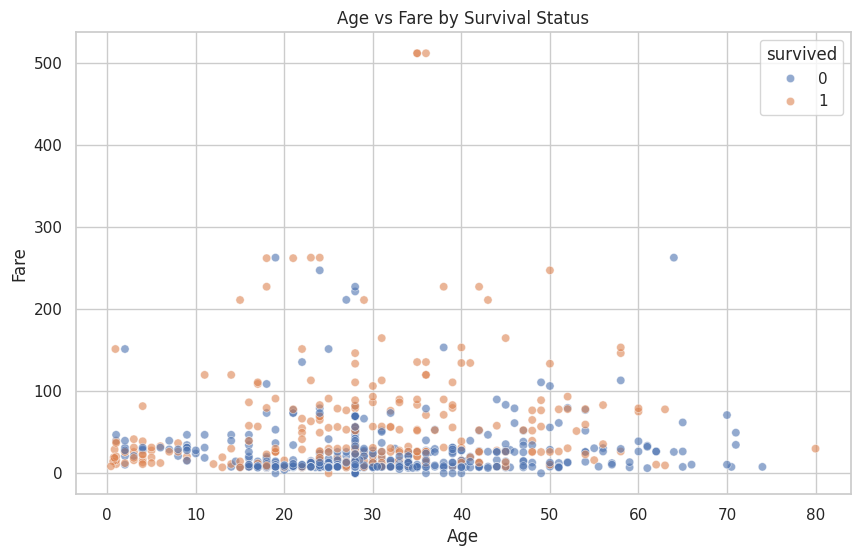

In [75]:
# Fare vs Age, colored by survival

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=clean_df,
    x="age",
    y="fare",
    hue="survived",
    alpha=0.6
)

plt.title("Age vs Fare by Survival Status")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.savefig(
    "/content/analytics/charts/age_fare_survival.png",
    bbox_inches="tight"
)

plt.show()

# Overall Titanic Data Story

The exploratory analysis indicates that survival was strongly associated with passenger sex and
passenger class. Female passengers had substantially higher survival rates than male passengers,
while first-class passengers generally had better survival outcomes than passengers in lower classes.

The combined sex and passenger-class analysis provides a more detailed picture: survival outcomes
varied across both characteristics, showing that multiple passenger attributes contributed to the
observed survival patterns.

Age also showed differences between survivors and non-survivors, although the distributions overlap,
suggesting that age alone was not sufficient to explain survival. Fare and passenger class were
moderately negatively correlated, reflecting the relationship between class and ticket price.

Overall, the exploratory analysis suggests that sex, passenger class, fare, age, and family-related
features may contain useful information for predicting Titanic survival. These observations provide
the motivation for building a predictive classification model in the next stage.

In [76]:
# Standardize Age and Fare

from sklearn.preprocessing import StandardScaler

scaler_eda = StandardScaler()

clean_df[["age_scaled", "fare_scaled"]] = scaler_eda.fit_transform(
    clean_df[["age", "fare"]]
)

In [77]:
# Compare befor after

standardization_summary = pd.DataFrame({
    "Original Mean": [
        clean_df["age"].mean(),
        clean_df["fare"].mean()
    ],

    "Original Std": [
        clean_df["age"].std(),
        clean_df["fare"].std()
    ],

    "Scaled Mean": [
        clean_df["age_scaled"].mean(),
        clean_df["fare_scaled"].mean()
    ],

    "Scaled Std": [
        clean_df["age_scaled"].std(),
        clean_df["fare_scaled"].std()
    ]
}, index=["age", "fare"])

display(standardization_summary)

,Original Mean,Original Std,Scaled Mean,Scaled Std
age,29.3152,12.9849,0.0000,1.0006
fare,32.0967,49.6975,0.0000,1.0006


In [78]:
print("Age scaled mean:", clean_df["age_scaled"].mean())
print(
    "Age scaled population std:",
    clean_df["age_scaled"].std(ddof=0)
)

print("\nFare scaled mean:", clean_df["fare_scaled"].mean())
print(
    "Fare scaled population std:",
    clean_df["fare_scaled"].std(ddof=0)
)

Age scaled mean: 2.717486278497571e-16
Age scaled population std: 0.9999999999999986

Fare scaled mean: 1.3987061727561027e-16
Fare scaled population std: 0.999999999999999


## Standardization Check

The `age` and `fare` columns were standardized using `StandardScaler`.
After transformation, both columns have means approximately equal to 0 and
population standard deviations approximately equal to 1.

This standardization was performed only as an exploratory data-analysis sanity check.
It is not used as the modeling preprocessing. The predictive modeling pipeline will
fit its own scaler only on the training data to prevent test-set information leakage.

In [ ]:
#  Predictive Modeling

In [79]:
# Features we will use for classification
feature_columns = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

X = clean_df[feature_columns].copy()

y = clean_df["survived"].copy()

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())

Feature shape: (889, 7)
Target shape: (889,)


,pclass,sex,age,sibsp,parch,fare,embarked
0,3,male,22.0000,1,0,7.2500,S
1,1,female,38.0000,1,0,71.2833,C
2,3,female,26.0000,0,0,7.9250,S
3,1,female,35.0000,1,0,53.1000,S
4,3,male,35.0000,0,0,8.0500,S


In [80]:
# Check the target class balance

class_counts = y.value_counts().sort_index()

print("Class counts:")
display(class_counts)

print("\nClass percentages:")

class_percentages = (
    y.value_counts(normalize=True)
    .sort_index() * 100
)

display(class_percentages)

Class counts:


,count
survived,
0,549
1,340



Class percentages:


,proportion
survived,
0,61.7548
1,38.2452


In [81]:
print(
    f"Did not survive (0): {class_counts[0]} "
    f"({class_percentages[0]:.2f}%)"
)

print(
    f"Survived (1): {class_counts[1]} "
    f"({class_percentages[1]:.2f}%)"
)

Did not survive (0): 549 (61.75%)
Survived (1): 340 (38.25%)


In [82]:
# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTraining target distribution:")
display(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
display(y_test.value_counts(normalize=True))

Training features: (711, 7)
Testing features: (178, 7)

Training target distribution:


,proportion
survived,
0,0.6174
1,0.3826



Testing target distribution:


,proportion
survived,
0,0.6180
1,0.3820


In [83]:
numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked"
]

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['pclass', 'age', 'sibsp', 'parch', 'fare']

Categorical features:
['sex', 'embarked']


In [85]:
# Numeric preprocessing pipeline

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [86]:
# Categorical preprocessing pipeline

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [87]:
#  Combine them using ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [88]:
preprocessor.fit(X)

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['pclass', 'age', 'sibsp', 'parch', 'fare']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['sex', 'embarked'])])

In [95]:
print("X_train exists:", "X_train" in globals())
print("y_train exists:", "y_train" in globals())
print("preprocessor exists:", "preprocessor" in globals())

X_train exists: True
y_train exists: True
preprocessor exists: True


In [96]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

print("Logistic Regression pipeline created successfully!")

Logistic Regression pipeline created successfully!


In [97]:
logistic_pipeline.fit(
    X_train,
    y_train
)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [98]:
logistic_predictions = logistic_pipeline.predict(X_test)

logistic_probabilities = logistic_pipeline.predict_proba(
    X_test
)[:, 1]

print("Predictions created successfully!")
print(logistic_predictions[:20])

Predictions created successfully!
[0 0 0 0 0 1 0 1 1 0 0 1 1 1 1 1 1 1 0 0]


In [99]:
logistic_accuracy = accuracy_score(y_test, logistic_predictions)
logistic_precision = precision_score(y_test, logistic_predictions)
logistic_recall = recall_score(y_test, logistic_predictions)
logistic_f1 = f1_score(y_test, logistic_predictions)
logistic_auc = roc_auc_score(y_test, logistic_probabilities)

print("Logistic Regression Results")
print("=" * 40)
print(f"Accuracy : {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall   : {logistic_recall:.4f}")
print(f"F1 Score : {logistic_f1:.4f}")
print(f"AUC      : {logistic_auc:.4f}")

Logistic Regression Results
Accuracy : 0.8090
Precision: 0.7833
Recall   : 0.6912
F1 Score : 0.7344
AUC      : 0.8610


In [101]:
# Create the Logistic Regression pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

print("Logistic Regression pipeline created successfully!")

Logistic Regression pipeline created successfully!


In [102]:
# Train

logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [103]:
# Make predictions

logistic_predictions = logistic_pipeline.predict(X_test)

logistic_probabilities = logistic_pipeline.predict_proba(X_test)[:, 1]

print("Predictions created successfully!")
print(logistic_predictions[:20])

Predictions created successfully!
[0 0 0 0 0 1 0 1 1 0 0 1 1 1 1 1 1 1 0 0]


In [104]:
# Calculate all required metrics

logistic_accuracy = accuracy_score(y_test, logistic_predictions)
logistic_precision = precision_score(y_test, logistic_predictions)
logistic_recall = recall_score(y_test, logistic_predictions)
logistic_f1 = f1_score(y_test, logistic_predictions)
logistic_auc = roc_auc_score(y_test, logistic_probabilities)

print("Logistic Regression Results")
print("=" * 40)
print(f"Accuracy : {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall   : {logistic_recall:.4f}")
print(f"F1 Score : {logistic_f1:.4f}")
print(f"AUC      : {logistic_auc:.4f}")

Logistic Regression Results
Accuracy : 0.8090
Precision: 0.7833
Recall   : 0.6912
F1 Score : 0.7344
AUC      : 0.8610


In [105]:
# Confusion matrix

logistic_cm = confusion_matrix(
    y_test,
    logistic_predictions
)

print("Logistic Regression Confusion Matrix:")
print(logistic_cm)

Logistic Regression Confusion Matrix:
[[97 13]
 [21 47]]


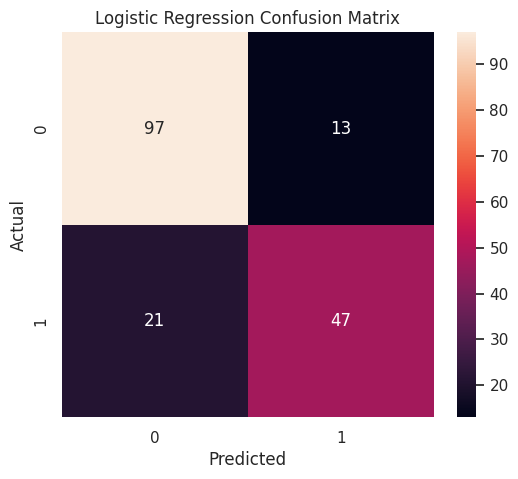

In [106]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [107]:
# Decision Tree

decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42,
                max_depth=5
            )
        )
    ]
)

print("Decision Tree pipeline created successfully!")

Decision Tree pipeline created successfully!


In [108]:
# Train the Decision Tree

decision_tree_pipeline.fit(
    X_train,
    y_train
)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [109]:
# Make predictions

decision_tree_predictions = decision_tree_pipeline.predict(X_test)

decision_tree_probabilities = (
    decision_tree_pipeline.predict_proba(X_test)[:, 1]
)

print("Decision Tree predictions created successfully!")

Decision Tree predictions created successfully!


In [110]:
# Evaluate Decision Tree

decision_tree_accuracy = accuracy_score(
    y_test,
    decision_tree_predictions
)

decision_tree_precision = precision_score(
    y_test,
    decision_tree_predictions
)

decision_tree_recall = recall_score(
    y_test,
    decision_tree_predictions
)

decision_tree_f1 = f1_score(
    y_test,
    decision_tree_predictions
)

decision_tree_auc = roc_auc_score(
    y_test,
    decision_tree_probabilities
)

print("Decision Tree Results")
print("=" * 40)

print(f"Accuracy : {decision_tree_accuracy:.4f}")
print(f"Precision: {decision_tree_precision:.4f}")
print(f"Recall   : {decision_tree_recall:.4f}")
print(f"F1 Score : {decision_tree_f1:.4f}")
print(f"AUC      : {decision_tree_auc:.4f}")

Decision Tree Results
Accuracy : 0.7640
Precision: 0.7600
Recall   : 0.5588
F1 Score : 0.6441
AUC      : 0.8374


In [111]:
# Decision Tree Confusion Matrix

decision_tree_cm = confusion_matrix(
    y_test,
    decision_tree_predictions
)

print("Decision Tree Confusion Matrix:")
print(decision_tree_cm)

Decision Tree Confusion Matrix:
[[98 12]
 [30 38]]


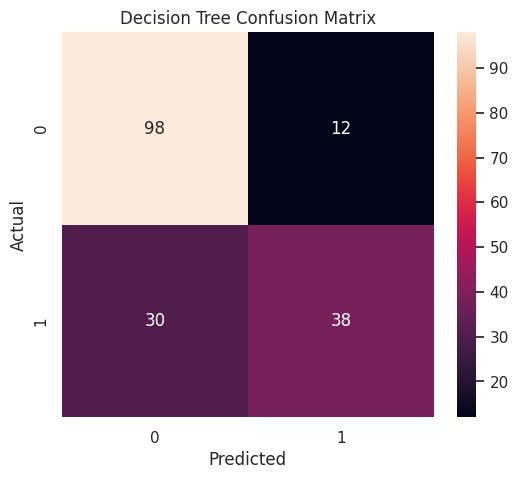

In [112]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    decision_tree_cm,
    annot=True,
    fmt="d"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [113]:

# Get the fitted preprocessor
fitted_preprocessor = (
    decision_tree_pipeline
    .named_steps["preprocessor"]
)

# Get feature names after preprocessing
feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

print("Number of transformed features:", len(feature_names))
print("\nFeature names:")
print(feature_names)

Number of transformed features: 10

Feature names:
['numeric__pclass' 'numeric__age' 'numeric__sibsp' 'numeric__parch'
 'numeric__fare' 'categorical__sex_female' 'categorical__sex_male'
 'categorical__embarked_C' 'categorical__embarked_Q'
 'categorical__embarked_S']


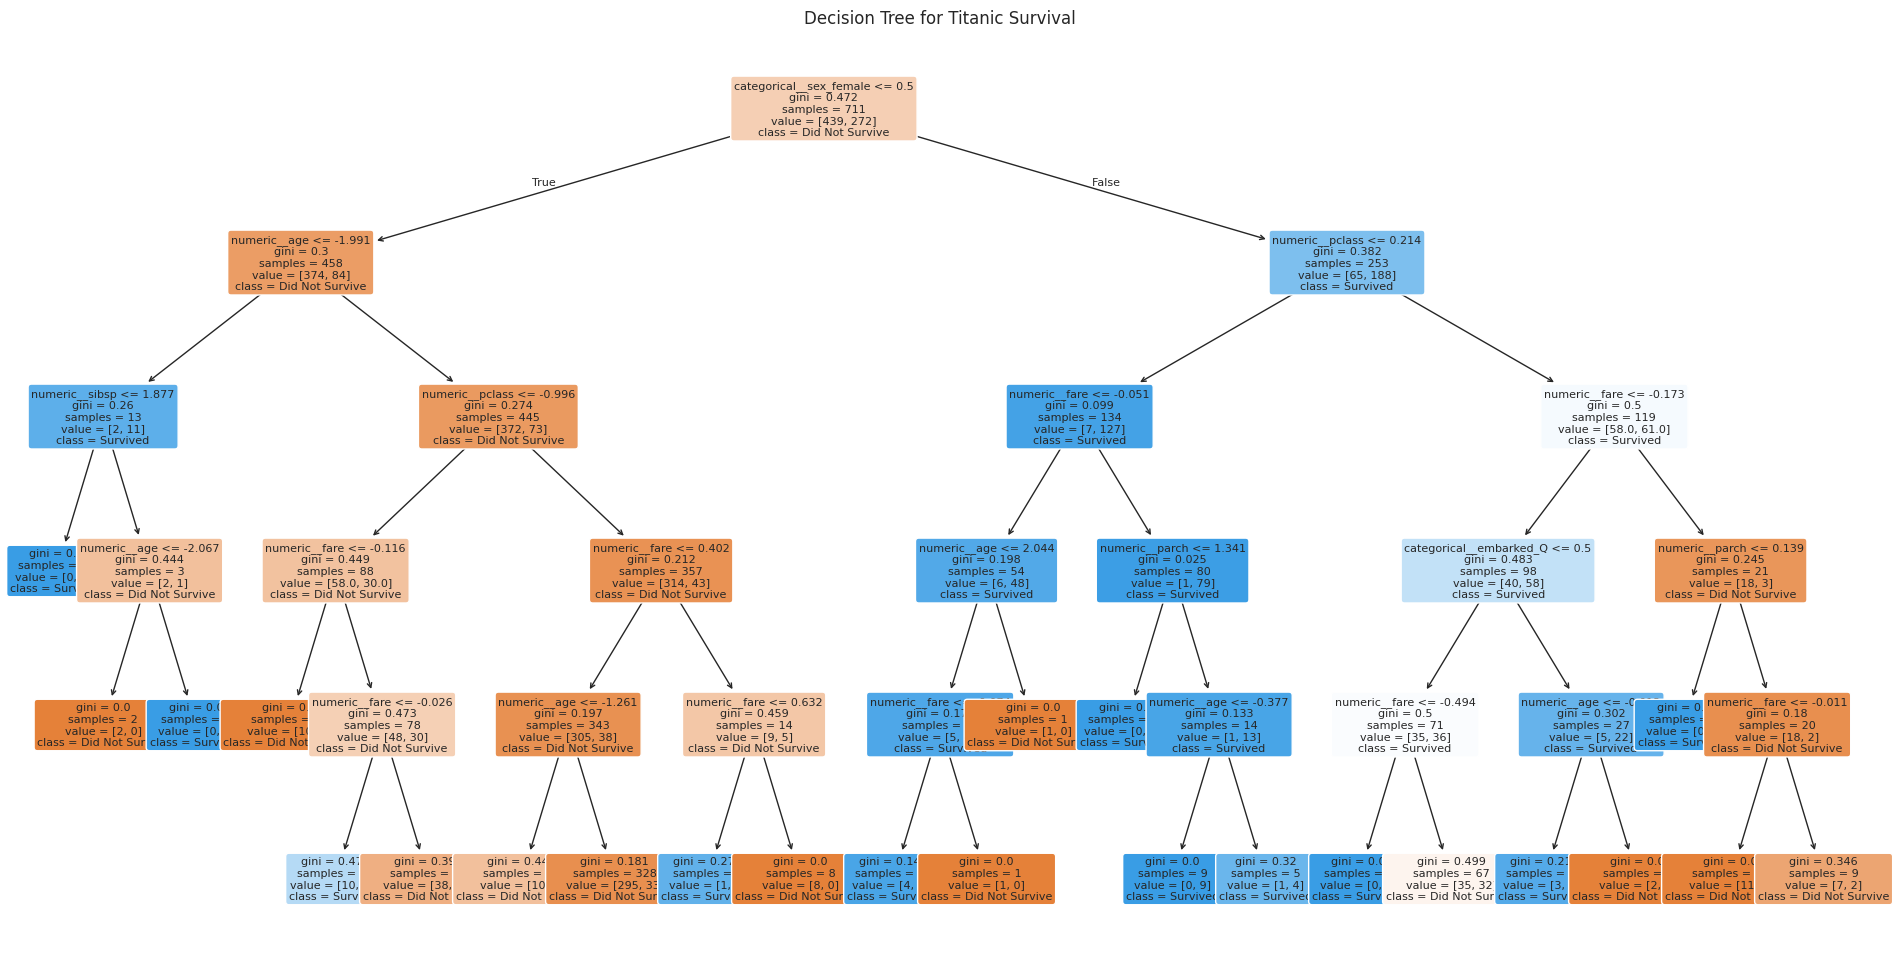

In [114]:
# Plot the Decision Tree

tree_model = decision_tree_pipeline.named_steps["classifier"]

plt.figure(figsize=(24, 12))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["Did Not Survive", "Survived"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree for Titanic Survival")

plt.savefig(
    "/content/analytics/charts/decision_tree.png",
    bbox_inches="tight"
)

plt.show()

In [115]:
#  Save Decision Tree results

decision_tree_results = {
    "Model": "Decision Tree",
    "Accuracy": decision_tree_accuracy,
    "Precision": decision_tree_precision,
    "Recall": decision_tree_recall,
    "F1": decision_tree_f1,
    "AUC": decision_tree_auc
}

decision_tree_results

{'Model': 'Decision Tree',
 'Accuracy': 0.7640449438202247,
 'Precision': 0.76,
 'Recall': 0.5588235294117647,
 'F1': 0.6440677966101694,
 'AUC': np.float64(0.8373663101604277)}

In [116]:
# Random Forest

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

print("Random Forest pipeline created successfully!")

Random Forest pipeline created successfully!


In [118]:
# train

random_forest_pipeline.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [119]:
# Make predictions

random_forest_predictions = random_forest_pipeline.predict(X_test)

random_forest_probabilities = (
    random_forest_pipeline.predict_proba(X_test)[:, 1]
)

print("Random Forest predictions created successfully!")

Random Forest predictions created successfully!


In [120]:
# Calculate all required metrics

random_forest_accuracy = accuracy_score(
    y_test,
    random_forest_predictions
)

random_forest_precision = precision_score(
    y_test,
    random_forest_predictions
)

random_forest_recall = recall_score(
    y_test,
    random_forest_predictions
)

random_forest_f1 = f1_score(
    y_test,
    random_forest_predictions
)

random_forest_auc = roc_auc_score(
    y_test,
    random_forest_probabilities
)

print("Random Forest Results")
print("=" * 40)

print(f"Accuracy : {random_forest_accuracy:.4f}")
print(f"Precision: {random_forest_precision:.4f}")
print(f"Recall   : {random_forest_recall:.4f}")
print(f"F1 Score : {random_forest_f1:.4f}")
print(f"AUC      : {random_forest_auc:.4f}")

Random Forest Results
Accuracy : 0.8090
Precision: 0.7656
Recall   : 0.7206
F1 Score : 0.7424
AUC      : 0.8196


In [121]:
# Confusion matrix

random_forest_cm = confusion_matrix(
    y_test,
    random_forest_predictions
)

print("Random Forest Confusion Matrix:")
print(random_forest_cm)



Random Forest Confusion Matrix:
[[95 15]
 [19 49]]


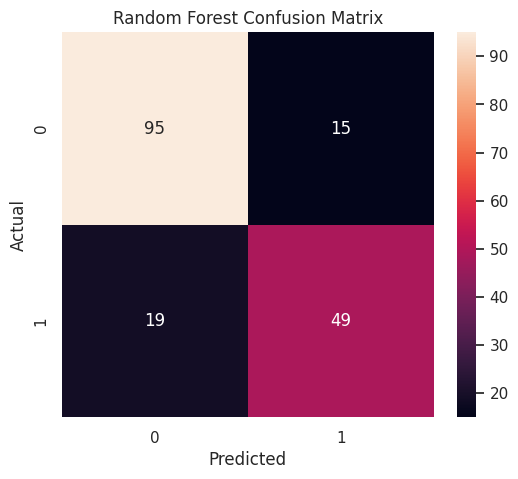

In [122]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    random_forest_cm,
    annot=True,
    fmt="d"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [123]:
 #  comparison table

 classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        logistic_accuracy,
        decision_tree_accuracy,
        random_forest_accuracy
    ],

    "Precision": [
        logistic_precision,
        decision_tree_precision,
        random_forest_precision
    ],

    "Recall": [
        logistic_recall,
        decision_tree_recall,
        random_forest_recall
    ],

    "F1": [
        logistic_f1,
        decision_tree_f1,
        random_forest_f1
    ],

    "AUC": [
        logistic_auc,
        decision_tree_auc,
        random_forest_auc
    ]
})

display(
    classification_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "AUC": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.8090,0.7833,0.6912,0.7344,0.8610
1,Decision Tree,0.7640,0.7600,0.5588,0.6441,0.8374
2,Random Forest,0.8090,0.7656,0.7206,0.7424,0.8196


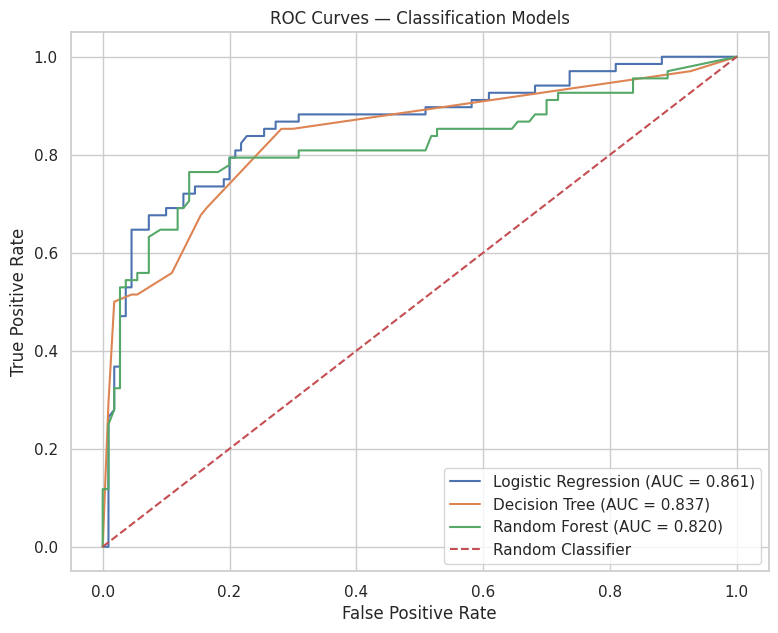

In [124]:
# ROC Curves for all 3 models

# Logistic Regression
fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test,
    logistic_probabilities
)

# Decision Tree
fpr_tree, tpr_tree, _ = roc_curve(
    y_test,
    decision_tree_probabilities
)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    random_forest_probabilities
)

plt.figure(figsize=(9, 7))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {logistic_auc:.3f})"
)

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Decision Tree (AUC = {decision_tree_auc:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {random_forest_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Classification Models")
plt.legend()

plt.savefig(
    "/content/analytics/charts/roc_curves.png",
    bbox_inches="tight"
)

plt.show()

In [125]:
# Class Imbalance

print("Training class distribution:")
display(y_train.value_counts())

print("\nTraining class percentages:")
display(
    y_train.value_counts(normalize=True).mul(100).round(2)
)

Training class distribution:


,count
survived,
0,439
1,272



Training class percentages:


,proportion
survived,
0,61.7400
1,38.2600


In [126]:
# Class Weighting

random_forest_balanced = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

print("Balanced Random Forest pipeline created!")

Balanced Random Forest pipeline created!


In [127]:
random_forest_balanced.fit(
    X_train,
    y_train
)

print("Balanced Random Forest trained!")

Balanced Random Forest trained!


In [128]:
# Predict

rf_balanced_predictions = (
    random_forest_balanced.predict(X_test)
)

rf_balanced_probabilities = (
    random_forest_balanced.predict_proba(X_test)[:, 1]
)

In [129]:
# Evaluate

rf_balanced_accuracy = accuracy_score(
    y_test,
    rf_balanced_predictions
)

rf_balanced_precision = precision_score(
    y_test,
    rf_balanced_predictions
)

rf_balanced_recall = recall_score(
    y_test,
    rf_balanced_predictions
)

rf_balanced_f1 = f1_score(
    y_test,
    rf_balanced_predictions
)

rf_balanced_auc = roc_auc_score(
    y_test,
    rf_balanced_probabilities
)

print("Random Forest — Balanced Class Weights")
print("=" * 45)
print(f"Accuracy : {rf_balanced_accuracy:.4f}")
print(f"Precision: {rf_balanced_precision:.4f}")
print(f"Recall   : {rf_balanced_recall:.4f}")
print(f"F1 Score : {rf_balanced_f1:.4f}")
print(f"AUC      : {rf_balanced_auc:.4f}")

Random Forest — Balanced Class Weights
Accuracy : 0.8090
Precision: 0.7656
Recall   : 0.7206
F1 Score : 0.7424
AUC      : 0.8165


In [130]:
# SMOTE

X_train_transformed = preprocessor.fit_transform(X_train)

X_test_transformed = preprocessor.transform(X_test)

print("Training transformed shape:", X_train_transformed.shape)
print("Testing transformed shape:", X_test_transformed.shape)

Training transformed shape: (711, 10)
Testing transformed shape: (178, 10)


In [131]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_transformed,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
survived
0    439
1    272
Name: count, dtype: int64

After SMOTE:
survived
1    439
0    439
Name: count, dtype: int64


In [132]:
#  Train Random Forest on SMOTE data

rf_smote_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [133]:
rf_smote_model.fit(
    X_train_smote,
    y_train_smote
)

print("SMOTE Random Forest trained!")

SMOTE Random Forest trained!


In [134]:
X_train_smote
y_train_smote

,survived
0,1
1,0
2,0
3,1
4,1
...,...
873,1
874,1
875,1
876,1


In [135]:
# Evaluate SMOTE model

X_test_transformed

array([[ 0.81860038,  1.12162871, -0.46844129, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.81860038, -0.10787086, -0.46844129, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.81860038, -0.10787086, -0.46844129, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-0.39143054, -0.10787086, -0.46844129, ...,  0.        ,
         0.        ,  1.        ],
       [-1.60146146, -1.02999554, -0.46844129, ...,  0.        ,
         0.        ,  1.        ],
       [-0.39143054,  0.12266031,  0.46976084, ...,  0.        ,
         0.        ,  1.        ]])

In [136]:
rf_smote_predictions = rf_smote_model.predict(
    X_test_transformed
)

rf_smote_probabilities = rf_smote_model.predict_proba(
    X_test_transformed
)[:, 1]

In [137]:
rf_smote_accuracy = accuracy_score(
    y_test,
    rf_smote_predictions
)

rf_smote_precision = precision_score(
    y_test,
    rf_smote_predictions
)

rf_smote_recall = recall_score(
    y_test,
    rf_smote_predictions
)

rf_smote_f1 = f1_score(
    y_test,
    rf_smote_predictions
)

rf_smote_auc = roc_auc_score(
    y_test,
    rf_smote_probabilities
)

print("Random Forest — SMOTE")
print("=" * 35)
print(f"Accuracy : {rf_smote_accuracy:.4f}")
print(f"Precision: {rf_smote_precision:.4f}")
print(f"Recall   : {rf_smote_recall:.4f}")
print(f"F1 Score : {rf_smote_f1:.4f}")
print(f"AUC      : {rf_smote_auc:.4f}")

Random Forest — SMOTE
Accuracy : 0.8146
Precision: 0.7612
Recall   : 0.7500
F1 Score : 0.7556
AUC      : 0.8267


In [138]:
# Create the imbalance comparison table

imbalance_results = pd.DataFrame({
    "Approach": [
        "Baseline Random Forest",
        "Class Weight = Balanced",
        "SMOTE"
    ],

    "Accuracy": [
        random_forest_accuracy,
        rf_balanced_accuracy,
        rf_smote_accuracy
    ],

    "Precision": [
        random_forest_precision,
        rf_balanced_precision,
        rf_smote_precision
    ],

    "Recall": [
        random_forest_recall,
        rf_balanced_recall,
        rf_smote_recall
    ],

    "F1": [
        random_forest_f1,
        rf_balanced_f1,
        rf_smote_f1
    ],

    "AUC": [
        random_forest_auc,
        rf_balanced_auc,
        rf_smote_auc
    ]
})

display(
    imbalance_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "AUC": "{:.4f}"
    })
)

,Approach,Accuracy,Precision,Recall,F1,AUC
0,Baseline Random Forest,0.8090,0.7656,0.7206,0.7424,0.8196
1,Class Weight = Balanced,0.8090,0.7656,0.7206,0.7424,0.8165
2,SMOTE,0.8146,0.7612,0.7500,0.7556,0.8267


## Class Imbalance Comparison

Three Random Forest approaches were compared: the baseline model, class weighting
using `class_weight="balanced"`, and SMOTE applied only to the training data.

The balanced class-weight approach produced the same accuracy, precision, recall,
and F1 score as the baseline model, while its AUC decreased slightly from 0.8196
to 0.8165. Therefore, class weighting did not provide a meaningful improvement
for this dataset and train/test split.

SMOTE produced the strongest overall results. Accuracy increased to 0.8146,
recall increased to 0.7500, F1 increased to 0.7556, and AUC increased to 0.8267.
Although precision decreased slightly to 0.7612, the improvement in recall and F1
suggests that SMOTE was the preferable imbalance-handling strategy among the
three approaches tested.

SMOTE was applied only to the training data, while the original test data was
kept unchanged for unbiased evaluation.

In [139]:
#  comparison table permanently

imbalance_results = pd.DataFrame({
    "Approach": [
        "Baseline Random Forest",
        "Balanced Class Weight",
        "SMOTE"
    ],
    "Accuracy": [
        random_forest_accuracy,
        rf_balanced_accuracy,
        rf_smote_accuracy
    ],
    "Precision": [
        random_forest_precision,
        rf_balanced_precision,
        rf_smote_precision
    ],
    "Recall": [
        random_forest_recall,
        rf_balanced_recall,
        rf_smote_recall
    ],
    "F1": [
        random_forest_f1,
        rf_balanced_f1,
        rf_smote_f1
    ],
    "AUC": [
        random_forest_auc,
        rf_balanced_auc,
        rf_smote_auc
    ]
})

display(
    imbalance_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "AUC": "{:.4f}"
    })
)

,Approach,Accuracy,Precision,Recall,F1,AUC
0,Baseline Random Forest,0.8090,0.7656,0.7206,0.7424,0.8196
1,Balanced Class Weight,0.8090,0.7656,0.7206,0.7424,0.8165
2,SMOTE,0.8146,0.7612,0.7500,0.7556,0.8267


In [140]:
n_estimators=200

In [142]:
#  Create the GridSearch pipeline

from sklearn.model_selection import GridSearchCV

rf_pipeline_for_tuning = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                random_state=42,
                oob_score=True,
                bootstrap=True
            )
        )
    ]
)

In [144]:
# Define the parameter grid

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 5, 10],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2]
}


In [145]:
# Run GridSearchCV

grid_search = GridSearchCV(
    estimator=rf_pipeline_for_tuning,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['pclass',
                                                                          'age',
                                                                          'sibsp',
                                                                          'parch',
                                                                          'fare']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['sex',
                                                                          'embarked'])])),
                                       ('classifier',
                                        RandomForestClassifier(oob_score=True,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [None, 5, 10],
                         'classifier__min_samples_leaf': [1, 2],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [100, 200]},
             scoring='f1', verbose=1)

In [146]:
# best parameters

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}


In [147]:
print("\nBest Cross-Validation F1 Score:")
print(f"{grid_search.best_score_:.4f}")


Best Cross-Validation F1 Score:
0.7519


In [148]:
# Get the tuned model

best_rf_pipeline = grid_search.best_estimator_

print("Best Random Forest pipeline obtained!")

Best Random Forest pipeline obtained!


In [149]:
tuned_rf_predictions = best_rf_pipeline.predict(X_test)

tuned_rf_probabilities = (
    best_rf_pipeline.predict_proba(X_test)[:, 1]
)

In [150]:
# Evaluate tuned Random Forest

tuned_rf_accuracy = accuracy_score(
    y_test,
    tuned_rf_predictions
)

tuned_rf_precision = precision_score(
    y_test,
    tuned_rf_predictions
)

tuned_rf_recall = recall_score(
    y_test,
    tuned_rf_predictions
)

tuned_rf_f1 = f1_score(
    y_test,
    tuned_rf_predictions
)

tuned_rf_auc = roc_auc_score(
    y_test,
    tuned_rf_probabilities
)

print("Tuned Random Forest Results")
print("=" * 40)

print(f"Accuracy : {tuned_rf_accuracy:.4f}")
print(f"Precision: {tuned_rf_precision:.4f}")
print(f"Recall   : {tuned_rf_recall:.4f}")
print(f"F1 Score : {tuned_rf_f1:.4f}")
print(f"AUC      : {tuned_rf_auc:.4f}")

Tuned Random Forest Results
Accuracy : 0.8034
Precision: 0.8000
Recall   : 0.6471
F1 Score : 0.7154
AUC      : 0.8235


In [151]:
# Get the OOB score

best_rf_model = (
    best_rf_pipeline
    .named_steps["classifier"]
)

print(
    "Random Forest OOB Score:",
    f"{best_rf_model.oob_score_:.4f}"
)


Random Forest OOB Score: 0.8270


In [152]:
# Save the tuning results

tuned_rf_summary = pd.DataFrame({
    "Metric": [
        "Best CV F1",
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1",
        "Test AUC",
        "OOB Score"
    ],
    "Value": [
        grid_search.best_score_,
        tuned_rf_accuracy,
        tuned_rf_precision,
        tuned_rf_recall,
        tuned_rf_f1,
        tuned_rf_auc,
        best_rf_model.oob_score_
    ]
})

display(
    tuned_rf_summary.style.format({
        "Value": "{:.4f}"
    })
)

,Metric,Value
0,Best CV F1,0.7519
1,Test Accuracy,0.8034
2,Test Precision,0.8000
3,Test Recall,0.6471
4,Test F1,0.7154
5,Test AUC,0.8235
6,OOB Score,0.8270


In [ ]:
# Regression

In [153]:
regression_features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "embarked"
]

X_reg = clean_df[regression_features].copy()

y_reg = clean_df["fare"].copy()

print("Regression features:")
display(X_reg.head())

print("\nRegression target:")
display(y_reg.head())

Regression features:


,pclass,sex,age,sibsp,parch,embarked
0,3,male,22.0000,1,0,S
1,1,female,38.0000,1,0,C
2,3,female,26.0000,0,0,S
3,1,female,35.0000,1,0,S
4,3,male,35.0000,0,0,S



Regression target:


,fare
0,7.2500
1,71.2833
2,7.9250
3,53.1000
4,8.0500


In [154]:
# Train/Test Split for Regression

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_reg_train.shape)
print("Testing features:", X_reg_test.shape)

print("Training target:", y_reg_train.shape)
print("Testing target:", y_reg_test.shape)

Training features: (711, 6)
Testing features: (178, 6)
Training target: (711,)
Testing target: (178,)


In [155]:
# Create regression preprocessing

reg_numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch"
]

In [156]:
reg_categorical_features = [
    "sex",
    "embarked"
]

In [157]:
reg_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [158]:
reg_categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [159]:
# Combine regression preprocessing

reg_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            reg_numeric_transformer,
            reg_numeric_features
        ),
        (
            "categorical",
            reg_categorical_transformer,
            reg_categorical_features
        )
    ]
)

print("Regression preprocessor created successfully!")

Regression preprocessor created successfully!


In [160]:
# Linear Regression

linear_regression_pipeline = Pipeline(
    steps=[
        ("preprocessor", reg_preprocessor),
        ("regressor", LinearRegression())
    ]
)

print("Linear Regression pipeline created!")

Linear Regression pipeline created!


In [161]:
linear_regression_pipeline.fit(
    X_reg_train,
    y_reg_train
)

print("Linear Regression trained successfully!")

Linear Regression trained successfully!


In [162]:
# Make predictions

linear_predictions = linear_regression_pipeline.predict(
    X_reg_test
)

print("First 10 predictions:")
print(linear_predictions[:10])

First 10 predictions:
[ -2.88475489  95.99511931  27.79356729  29.18366602  89.39234588
  -2.76586876  29.77809669  -2.05255195 100.4411708   84.37654661]


In [163]:
# Calculate RMSE, MAE and R²

linear_rmse = np.sqrt(
    mean_squared_error(
        y_reg_test,
        linear_predictions
    )
)

linear_mae = mean_absolute_error(
    y_reg_test,
    linear_predictions
)

linear_r2 = r2_score(
    y_reg_test,
    linear_predictions
)

print("Linear Regression Results")
print("=" * 40)

print(f"RMSE: {linear_rmse:.4f}")
print(f"MAE : {linear_mae:.4f}")
print(f"R²  : {linear_r2:.4f}")

Linear Regression Results
RMSE: 41.7465
MAE : 21.1386
R²  : 0.3468


In [165]:
from sklearn.ensemble import RandomForestRegressor

print("RandomForestRegressor imported successfully!")

RandomForestRegressor imported successfully!


In [166]:
# Random Forest Regressor pipeline

random_forest_regression_pipeline = Pipeline(
    steps=[
        ("preprocessor", reg_preprocessor),
        (
            "regressor",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

print("Random Forest Regressor pipeline created!")

Random Forest Regressor pipeline created!


In [167]:
# Train

random_forest_regression_pipeline.fit(
    X_reg_train,
    y_reg_train
)

print("Random Forest Regressor trained successfully!")

Random Forest Regressor trained successfully!


In [168]:
# Predict

rf_regression_predictions = (
    random_forest_regression_pipeline.predict(
        X_reg_test
    )
)

print("Predictions created!")

Predictions created!


In [169]:
# Evaluate

rf_regression_rmse = np.sqrt(
    mean_squared_error(
        y_reg_test,
        rf_regression_predictions
    )
)

rf_regression_mae = mean_absolute_error(
    y_reg_test,
    rf_regression_predictions
)

rf_regression_r2 = r2_score(
    y_reg_test,
    rf_regression_predictions
)

print("Random Forest Regressor Results")
print("=" * 40)

print(f"RMSE: {rf_regression_rmse:.4f}")
print(f"MAE : {rf_regression_mae:.4f}")
print(f"R²  : {rf_regression_r2:.4f}")

Random Forest Regressor Results
RMSE: 45.1814
MAE : 15.5844
R²  : 0.2349


## Regression Model Comparison

Linear Regression achieved an RMSE of 41.7465, MAE of 21.1386, and R² of
0.3468. Random Forest Regressor achieved an RMSE of 45.1814, MAE of 15.5844,
and R² of 0.2349.

Linear Regression performed better in terms of RMSE and R², indicating better
overall explanatory performance and fewer large prediction errors. Random
Forest Regressor achieved a lower MAE, indicating smaller average absolute
errors. Overall, Linear Regression is preferred based on the combination of
RMSE and R², while the lower MAE of Random Forest is also worth noting.

In [170]:
# Residual Analysis

linear_residuals = (
    y_reg_test - linear_predictions
)

rf_residuals = (
    y_reg_test - rf_regression_predictions
)

print("Linear Regression residuals:")
print(linear_residuals.head())

print("\nRandom Forest residuals:")
print(rf_residuals.head())

Linear Regression residuals:
281    10.7390
435    24.0049
39    -16.5519
418   -16.1837
585    -9.7423
Name: fare, dtype: float64

Random Forest residuals:
281   -3.0780
435   41.8654
39    -2.1684
418    0.2969
585   23.8653
Name: fare, dtype: float64


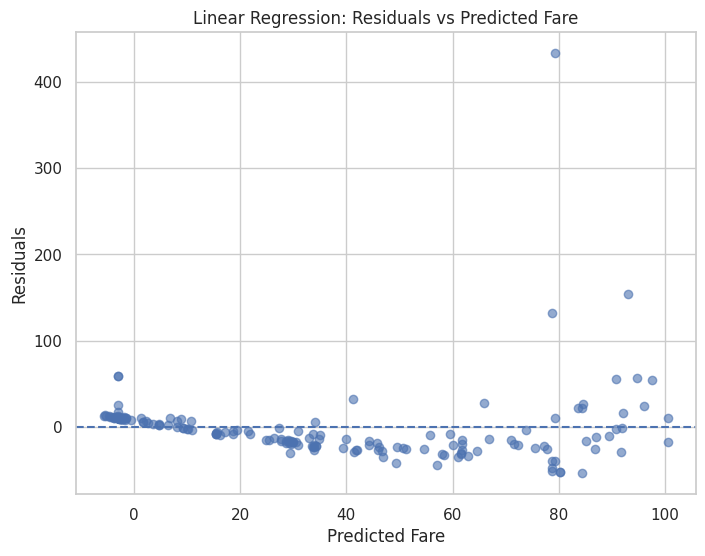

In [171]:
# Residual plot: Linear Regression

plt.figure(figsize=(8, 6))

plt.scatter(
    linear_predictions,
    linear_residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Linear Regression: Residuals vs Predicted Fare")

plt.savefig(
    "/content/analytics/charts/linear_regression_residuals.png",
    bbox_inches="tight"
)

plt.show()

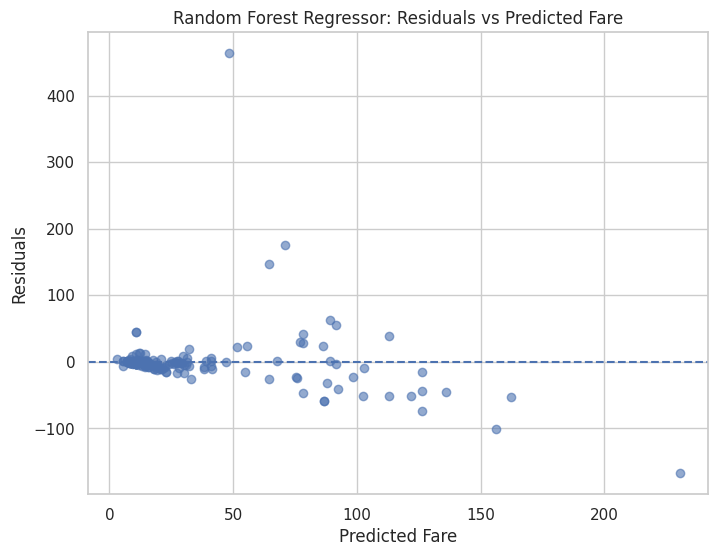

In [172]:
# Residual plot: Random Forest

plt.figure(figsize=(8, 6))

plt.scatter(
    rf_regression_predictions,
    rf_residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Random Forest Regressor: Residuals vs Predicted Fare")

plt.savefig(
    "/content/analytics/charts/random_forest_regression_residuals.png",
    bbox_inches="tight"
)

plt.show()

In [174]:
#  Heteroscedasticity Test

from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm



In [175]:
X_bp = sm.add_constant(linear_predictions)

bp_test = het_breuschpagan(
    linear_residuals,
    X_bp
)

bp_labels = [
    "LM Statistic",
    "LM-Test p-value",
    "F-Statistic",
    "F-Test p-value"
]

bp_results = dict(
    zip(bp_labels, bp_test)
)

print("Breusch-Pagan Test — Linear Regression")
print("=" * 45)

for key, value in bp_results.items():
    print(f"{key}: {value:.4f}")

Breusch-Pagan Test — Linear Regression
LM Statistic: 4.1837
LM-Test p-value: 0.0408
F-Statistic: 4.2363
F-Test p-value: 0.0410


In [177]:
regression_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest Regressor"
    ],
    "RMSE": [
        linear_rmse,
        rf_regression_rmse
    ],
    "MAE": [
        linear_mae,
        rf_regression_mae
    ],
    "R2": [
        linear_r2,
        rf_regression_r2
    ]
})

display(
    regression_results.style.format({
        "RMSE": "{:.4f}",
        "MAE": "{:.4f}",
        "R2": "{:.4f}"
    })
)

,Model,RMSE,MAE,R2
0,Linear Regression,41.7465,21.1386,0.3468
1,Random Forest Regressor,45.1814,15.5844,0.2349


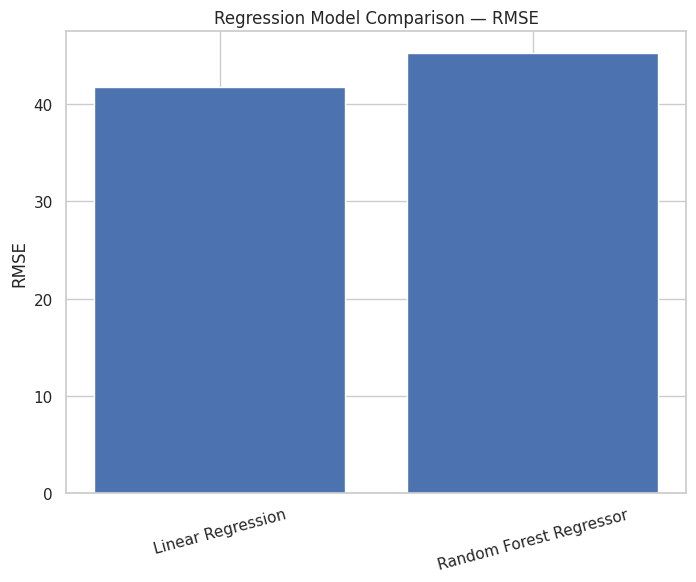

In [178]:
# Now create the RMSE chart

plt.figure(figsize=(8, 6))

plt.bar(
    regression_results["Model"],
    regression_results["RMSE"]
)

plt.ylabel("RMSE")
plt.title("Regression Model Comparison — RMSE")

plt.xticks(rotation=15)

plt.savefig(
    "/content/analytics/charts/regression_rmse_comparison.png",
    bbox_inches="tight"
)

plt.show()

## Heteroscedasticity Analysis

The Breusch-Pagan test was used to check whether the variance of the Linear
Regression residuals was constant.

The LM-test p-value was 0.0408 and the F-test p-value was 0.0410. Both values
are below the 0.05 significance level. Therefore, we reject the null hypothesis
of constant residual variance and conclude that there is evidence of
heteroscedasticity in the Linear Regression model.

This indicates that the prediction errors vary across different fare levels.
The residual plot should therefore be interpreted carefully, particularly
because higher fare observations may have larger prediction errors.

In [179]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nAnalytics folder:")
print(os.listdir("/content/analytics"))

Current working directory:
/content

Analytics folder:
['titanic.csv', 'charts']


In [180]:
# Create the submission folders

import os

folders = [
    "/content/analytics/charts",
    "/content/analytics/results",
    "/content/analytics/models"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Submission folders created successfully!")

print("\nAnalytics folder:")
print(os.listdir("/content/analytics"))

Submission folders created successfully!

Analytics folder:
['results', 'titanic.csv', 'charts', 'models']


In [181]:
# Save your classification results

classification_results.to_csv(
    "/content/analytics/results/classification_model_comparison.csv",
    index=False
)

print("Classification results saved!")

Classification results saved!


In [182]:
imbalance_results.to_csv(
    "/content/analytics/results/imbalance_comparison.csv",
    index=False
)

print("Imbalance results saved!")

Imbalance results saved!


In [183]:
# Save regression results

regression_results.to_csv(
    "/content/analytics/results/regression_model_comparison.csv",
    index=False
)

print("Regression results saved!")



Regression results saved!


In [184]:
# Save the GridSearch results

best_parameters = pd.DataFrame({
    "Parameter": list(grid_search.best_params_.keys()),
    "Best Value": list(grid_search.best_params_.values())
})

best_parameters.to_csv(
    "/content/analytics/results/random_forest_best_parameters.csv",
    index=False
)

print("Best parameters saved!")

Best parameters saved!


In [185]:
oob_results = pd.DataFrame({
    "Metric": ["Best CV F1", "OOB Score"],
    "Value": [
        grid_search.best_score_,
        best_rf_model.oob_score_
    ]
})

oob_results.to_csv(
    "/content/analytics/results/random_forest_cv_oob.csv",
    index=False
)

print("CV and OOB results saved!")

CV and OOB results saved!


In [186]:
#  Save the final SMOTE Random Forest model


import joblib

In [187]:
joblib.dump(
    preprocessor,
    "/content/analytics/models/smote_preprocessor.pkl"
)

joblib.dump(
    rf_smote_model,
    "/content/analytics/models/smote_random_forest.pkl"
)

print("SMOTE Random Forest model files saved!")

SMOTE Random Forest model files saved!


In [188]:
# Save the Logistic Regression model too


joblib.dump(
    logistic_pipeline,
    "/content/analytics/models/logistic_regression_pipeline.pkl"
)

print("Logistic Regression pipeline saved!")

Logistic Regression pipeline saved!


In [189]:
# Save a final model summary

final_model_summary = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest Baseline",
        "Random Forest SMOTE",
        "Random Forest Tuned"
    ],
    "Accuracy": [
        logistic_accuracy,
        decision_tree_accuracy,
        random_forest_accuracy,
        rf_smote_accuracy,
        tuned_rf_accuracy
    ],
    "Precision": [
        logistic_precision,
        decision_tree_precision,
        random_forest_precision,
        rf_smote_precision,
        tuned_rf_precision
    ],
    "Recall": [
        logistic_recall,
        decision_tree_recall,
        random_forest_recall,
        rf_smote_recall,
        tuned_rf_recall
    ],
    "F1": [
        logistic_f1,
        decision_tree_f1,
        random_forest_f1,
        rf_smote_f1,
        tuned_rf_f1
    ],
    "AUC": [
        logistic_auc,
        decision_tree_auc,
        random_forest_auc,
        rf_smote_auc,
        tuned_rf_auc
    ]
})

display(
    final_model_summary.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "AUC": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.8090,0.7833,0.6912,0.7344,0.8610
1,Decision Tree,0.7640,0.7600,0.5588,0.6441,0.8374
2,Random Forest Baseline,0.8090,0.7656,0.7206,0.7424,0.8196
3,Random Forest SMOTE,0.8146,0.7612,0.7500,0.7556,0.8267
4,Random Forest Tuned,0.8034,0.8000,0.6471,0.7154,0.8235


In [190]:
final_model_summary.to_csv(
    "/content/analytics/results/final_classification_summary.csv",
    index=False
)

print("Final classification summary saved!")

Final classification summary saved!


In [191]:
import os

for root, dirs, files in os.walk("/content/analytics"):
    level = root.replace("/content/analytics", "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    {file}")

analytics/
    titanic.csv
    results/
        imbalance_comparison.csv
        random_forest_best_parameters.csv
        final_classification_summary.csv
        random_forest_cv_oob.csv
        regression_model_comparison.csv
        classification_model_comparison.csv
    charts/
        correlation_heatmap.png
        age_histogram.png
        random_forest_regression_residuals.png
        fare_boxplot.png
        linear_regression_residuals.png
        survival_by_sex_pclass.png
        fare_histogram.png
        decision_tree.png
        age_boxplot.png
        age_by_survival.png
        survival_by_sex.png
        age_fare_survival.png
        regression_rmse_comparison.png
        roc_curves.png
        survival_by_pclass.png
    models/
        smote_random_forest.pkl
        smote_preprocessor.pkl
        logistic_regression_pipeline.pkl


In [192]:
import joblib

# Load Logistic Regression pipeline
loaded_logistic = joblib.load(
    "/content/analytics/models/logistic_regression_pipeline.pkl"
)

# Load SMOTE preprocessor
loaded_preprocessor = joblib.load(
    "/content/analytics/models/smote_preprocessor.pkl"
)

# Load SMOTE Random Forest
loaded_smote_rf = joblib.load(
    "/content/analytics/models/smote_random_forest.pkl"
)

print("All model files loaded successfully!")

All model files loaded successfully!


In [193]:
# Test the saved SMOTE model

loaded_test_data = loaded_preprocessor.transform(X_test)

loaded_predictions = loaded_smote_rf.predict(
    loaded_test_data
)

print("Saved model prediction test successful!")
print("Number of predictions:", len(loaded_predictions))
print("First 10 predictions:", loaded_predictions[:10])

Saved model prediction test successful!
Number of predictions: 178
First 10 predictions: [0 0 0 0 0 1 0 1 1 0]
